# EDA - Sample Analysis

Reference year: 2022

In [1]:
# SetUp

import os
import sys

# PROJ_DATA_PATH = "/opt/conda/envs/geospatial/share/proj"
PROJPATH = '/home/jovyan/projetos/proj_amazonia_dggs'
PROJBASEPATH = f'{PROJPATH}/proj_amazonia_dggs_base'

ENVPATH = f'{PROJBASEPATH}/env/proj_amazonia_dggs'
SRCPATH = f'{PROJBASEPATH}/src'

LOCALPATH = f'{PROJPATH}/amazonia_dggs_accuracy_experiments'
DATAPATH = f'{LOCALPATH}/data'
DOCPATH = f'{LOCALPATH}/docs'
LOCALSRCPATH = f'{LOCALPATH}/src'

os.environ['PROJ_DATA'] = f'{ENVPATH}/share/proj'
sys.path.append(SRCPATH)
sys.path.append(LOCALSRCPATH)

In [3]:
import geopandas as gpd
import numpy as np
import pandas as pd
from esda import shape as shapestats
import matplotlib.pyplot as plt

from scipy import stats
import crs_definitions, area_definitions

In [14]:
data_input_path =  f'{DATAPATH}/processed/sample/sample_with_metrics.parquet'
fig_output_folder =  f'{DOCPATH}/eda_sample'

In [5]:

data = gpd.read_parquet(data_input_path)


In [6]:
bins = area_definitions.FILTERED_BINS
categories = area_definitions.FILTERED_CATEGORIES


data['category'] = pd.cut(data['area'], bins=bins, labels=categories)

In [7]:
grouped_data = (
    data[['area', 'category']]
        .groupby('category', observed=True)
        .agg(count=('area', 'count'),
             area=('area', 'sum'))
        # .rename(columns={'area': 'count'})
        .reset_index()
)

grouped_data['prop_count'] = grouped_data['count'] / grouped_data['count'].sum()
grouped_data['prop_area'] = grouped_data['area'] / grouped_data['area'].sum()


In [8]:
data.shape

(19917, 8)

In [9]:
grouped_data

,category,count,area,prop_count,prop_area
0,(0.05-0.1],8239,583.670961,0.413667,0.083037
1,(0.1-0.2],5281,741.087167,0.265150,0.105432
2,(0.2-0.5],3813,1179.780297,0.191444,0.167844
3,(0.5-1],1374,953.044569,0.068986,0.135587
4,(1-5],1068,2059.661018,0.053623,0.293022
5,(5-10],103,710.629664,0.005171,0.101099
6,> 10,39,801.165098,0.001958,0.113979


### Distribution of geometry areas in the sample

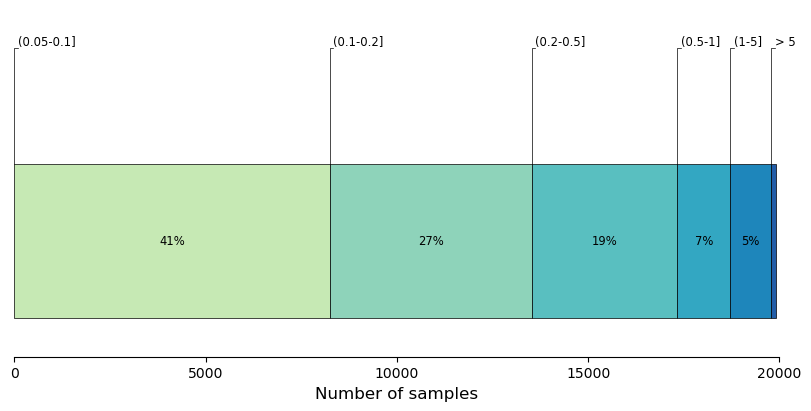

In [22]:

cumsum = 0
offset = 100
text_offset = 0.15
height = 0.20

colors = plt.cm.YlGnBu(np.linspace(0.25, 0.75, 6))
ticks = np.linspace(0, 20000, 5).astype(int)



fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')


for cat, count, prop, color in zip(grouped_data['category'].values[:-2],
                                   grouped_data['count'].values[:-2],
                                   grouped_data['prop_count'].values[:-2],
                                   colors):
    p = ax.barh(['sample'], width=count, height=height, left=cumsum,
                color=color, edgecolor='black', linewidth=0.5)
    l = ax.plot([cumsum, cumsum, cumsum + offset],
                [height / 2, height / 2 + text_offset, height / 2 + text_offset],
                "-", linewidth=0.5, color='black')
    ax.annotate(f'{cat}',
                xy=(cumsum + offset, height / 2 + text_offset),
                xytext=(0, 0),  # 4 points vertical offset.
                textcoords='offset points',
                ha='left', va='bottom', fontsize='small')
    ax.annotate(f'{prop:.0%}',
                xy=(cumsum + count / 2, 0),
                xytext=(0, 0),  # 4 points vertical offset.
                textcoords='offset points',
                ha='center', va='center', fontsize='small')
    cumsum += count

### Last category group (> 5 km²)
count = grouped_data['count'].values[-2:].sum()
color = colors[-1]
cat = '> 5'

p = ax.barh(['sample'], width=count, height=height, left=cumsum,
            color=color, edgecolor='black', linewidth=0.5)
l = ax.plot([cumsum, cumsum, cumsum + offset],
            [height / 2, height / 2 + text_offset, height / 2 + text_offset],
            "-", linewidth=0.5, color='black')
ax.annotate(f'{cat}',
            xy=(cumsum + offset, height / 2 + text_offset),
            xytext=(0, 0),  # 4 points vertical offset.
            textcoords='offset points',
            ha='left', va='bottom', fontsize='small')




ax.set_ylim(-0.15, 0.3)
ax.set_xlim(0, 20000)

ax.tick_params(left=False)
ax.set_yticklabels([])
ax.set_xticks(ticks=ticks,
              labels=ticks, fontsize=10)
ax.set_xlabel('Number of samples', fontsize=12)


ax.spines[['top', 'right', 'left']].set_visible(False)


plt.savefig(f'{fig_output_folder}/count_distribution.png', dpi=600)

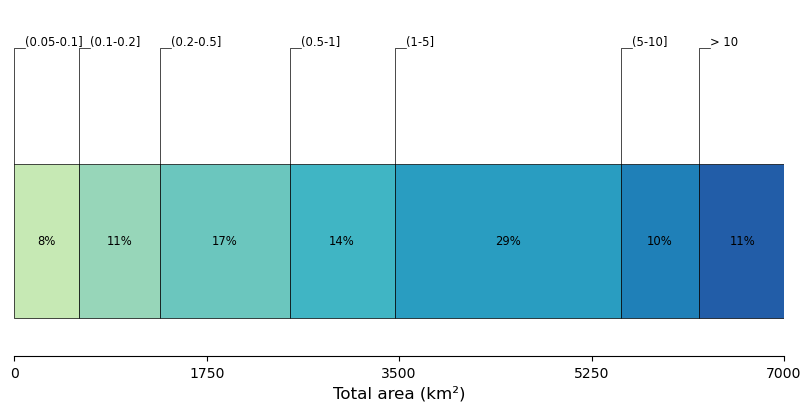

In [23]:

cumsum = 0
offset = 100
text_offset = 0.15
height = 0.20

colors = plt.cm.YlGnBu(np.linspace(0.25, 0.75, 7))
ticks = np.linspace(0, 7000, 5).astype(int)



fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')


for cat, count, prop, color in zip(grouped_data['category'].values,
                                   grouped_data['area'].values,
                                   grouped_data['prop_area'].values,
                                   colors):
    p = ax.barh(['sample'], width=count, height=height, left=cumsum,
                color=color, edgecolor='black', linewidth=0.5)
    l = ax.plot([cumsum, cumsum, cumsum + offset],
                [height / 2, height / 2 + text_offset, height / 2 + text_offset],
                "-", linewidth=0.5, color='black')
    ax.annotate(f'{cat}',
                xy=(cumsum + offset, height / 2 + text_offset),
                xytext=(0, 0),  # 4 points vertical offset.
                textcoords='offset points',
                ha='left', va='bottom', fontsize='small')
    ax.annotate(f'{prop:.0%}',
                xy=(cumsum + count / 2, 0),
                xytext=(0, 0),  # 4 points vertical offset.
                textcoords='offset points',
                ha='center', va='center', fontsize='small')
    cumsum += count

ax.set_ylim(-0.15, 0.3)
ax.set_xlim(0, 7000)

ax.tick_params(left=False)
ax.set_yticklabels([])
ax.set_xticks(ticks=ticks,
              labels=ticks, fontsize=10)
ax.set_xlabel('Total area (km²)', fontsize=12)


ax.spines[['top', 'right', 'left']].set_visible(False)


plt.savefig(f'{fig_output_folder}/area_distribution.png', dpi=600)

In [18]:
micd =[]
ba = []
for cat in categories:
    tmp = data.loc[data.category == cat]
    micd.append(tmp['micd'].values)
    ba.append(tmp['ba'].values)
    # n.append(tmp[f'n_{threshold}'].values)

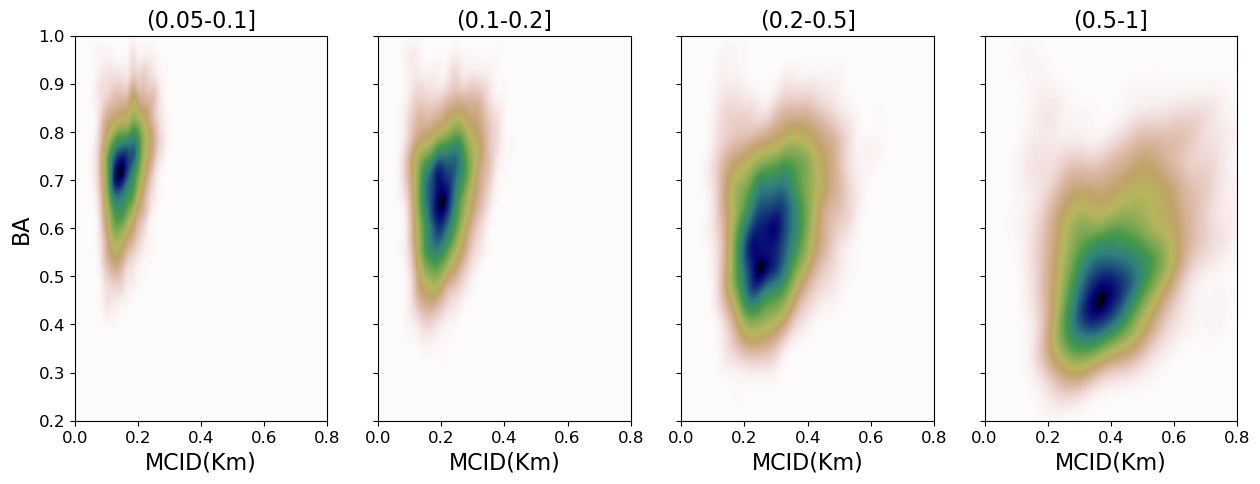

In [19]:
fig, ax = plt.subplots(ncols=4, figsize=(15, 5), sharey=True)

for i in range(4):
    m1, m2 =micd[i],  ba[i]
    
    # xmin = m1.min()
    # xmax = m1.max()
    # ymin = m2.min()
    # ymax = m2.max()

    xmin = 0
    xmax = 0.8
    ymin = 0.2
    ymax = 1
    
    values = np.stack([m1, m2])
    kernel = stats.gaussian_kde(values)
    
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions).T, X.shape)

    ax[i].imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
              extent=[xmin, xmax, ymin, ymax], aspect='auto')
    ax[i].set_xlabel('MCID(Km)', fontsize=16)
    ax[i].set_title(f'{categories[i]}', fontsize=16)
    ax[i].tick_params(labelsize=12)
    # ax.plot(m1, m2, 'k.', markersize=2)
    # ax[i].set_xlim([xmin, xmax])
    # ax[i].set_ylim([ymin, ymax])
    
    # ax[1].set_xlim([xmin, xmax])
    # ax[1].set_ylim([ymin, ymax])

ax[0].set_ylabel('BA', fontsize=16)

plt.savefig(f'{fig_output_folder}/relation_mcid_ba.png', dpi=600)